In [8]:
!pip install -q huggingface_hub

In [1]:
!git clone https://github.com/ROC-HCI/hal.git

Cloning into 'hal'...
remote: Enumerating objects: 263, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 263 (delta 16), reused 15 (delta 5), pack-reused 226 (from 2)
Receiving objects: 100% (263/263), 78.64 MiB | 22.37 MiB/s, done.
Resolving deltas: 100% (161/161), done.
Updating files: 100% (193/193), done.


In [128]:
cd hal

[Errno 2] No such file or directory: 'hal'
/content/hal


Synthlabs Train split data assessmet with **HAL16Q** questions

In [129]:
import pandas as pd

In [130]:
import os, json, time

In [131]:
from getpass import getpass

In [132]:
api_key = getpass("Please input your OpenAI API Key：")

Please input your OpenAI API Key：··········


# Dataset

## Human-Human PersonaChat
https://arxiv.org/abs/1801.07243

In [82]:
import re
from huggingface_hub import hf_hub_download


# Download the original PersonaChat training data.
file_path = hf_hub_download(
    repo_id="awsaf49/persona-chat",
    filename="test_both_original.txt",
    repo_type="dataset",
)

print("Downloaded to:", file_path)


def remove_turn_number(text: str) -> str:
    """Remove the numerical prefix, such as '1 ' or '12 '."""
    return re.sub(r"^\d+\s+", "", text).strip()


def parse_personachat(path: str, max_dialogues: int | None = None):
    """Parse PersonaChat into persona descriptions and complete dialogues."""

    dialogues = []
    current = {
        "speaker_a_persona": [],
        "speaker_b_persona": [],
        "turns": [],
    }

    with open(path, "r", encoding="utf-8") as file:
        for raw_line in file:
            line = raw_line.rstrip("\n")

            # A new conversation begins when numbering resets to 1
            # after the previous conversation already has dialogue turns.
            if line.startswith("1 your persona:") and current["turns"]:
                dialogues.append(current)

                if max_dialogues and len(dialogues) >= max_dialogues:
                    break

                current = {
                    "speaker_a_persona": [],
                    "speaker_b_persona": [],
                    "turns": [],
                }

            cleaned = remove_turn_number(line)

            if cleaned.startswith("your persona:"):
                persona = cleaned.removeprefix("your persona:").strip()
                current["speaker_a_persona"].append(persona)

            elif cleaned.startswith("partner's persona:"):
                persona = cleaned.removeprefix("partner's persona:").strip()
                current["speaker_b_persona"].append(persona)

            else:
                # Format:
                # utterance_A \t utterance_B \t response_candidates
                fields = line.split("\t")

                if len(fields) >= 2:
                    utterance_a = remove_turn_number(fields[0])
                    utterance_b = fields[1].strip()

                    current["turns"].append({
                        "speaker": "I",
                        "text": utterance_a,
                    })
                    current["turns"].append({
                        "speaker": "W",
                        "text": utterance_b,
                    })

        else:
            # Add the final conversation if the full file was processed.
            if current["turns"]:
                dialogues.append(current)

    return dialogues[:max_dialogues]


dialogues = parse_personachat(file_path, max_dialogues=50)

print(f"\nLoaded {len(dialogues)} dialogues.\n")


human_human = []

for dialogue_number, dialogue in enumerate(dialogues, start=1):
    print("=" * 100)
    print(f"DIALOGUE {dialogue_number}")
    print("=" * 100)

    print("\nI persona:")
    for fact in dialogue["speaker_a_persona"]:
        print(f"  - {fact}")

    print("\nW persona:")
    for fact in dialogue["speaker_b_persona"]:
        print(f"  - {fact}")

    print("\nConversation:")
    conversation = ""
    for turn in dialogue["turns"]:
        # print(f"{turn['speaker']}: {turn['text']}")
        conversation += f"{turn['speaker']}: {turn['text']}\n"
    human_human.append(conversation)
    print(conversation)


Downloaded to: /root/.cache/huggingface/hub/datasets--awsaf49--persona-chat/snapshots/3b72676fb095f45b8488bd5390394d3fad0d7e87/test_both_original.txt

Loaded 50 dialogues.

DIALOGUE 1

I persona:
  - i love to meet new people.
  - i have a turtle named timothy.
  - my favorite sport is ultimate frisbee.
  - my parents are living in bora bora.
  - autumn is my favorite season.

W persona:
  - i just bought a brand new house.
  - i like to dance at the club.
  - i run a dog obedience school.
  - i have a big sweet tooth.
  - i like taking and posting selkies.

Conversation:
I: hello , how are you doing tonight ?
W: i am well an loving this interaction how are you ?
I: i am great . i just got back from the club .
W: this is my favorite time of the year season wise
I: i would rather eat chocolate cake during this season .
W: what club did you go to ? me an timothy watched tv
I: i went to club chino . what show are you watching ?
W: lol oh okay kind of random
I: do you live in a house or ap

## Synthetic PersonaChat AI-AI

https://arxiv.org/abs/2312.10007

In [115]:
import pandas as pd

url = (
    "https://raw.githubusercontent.com/"
    "google-research-datasets/Synthetic-Persona-Chat/"
    "main/data/Synthetic-Persona-Chat_test.csv"
)

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

ai_ai = []

for index, row in df.head(50).iterrows():
    print("\n" + "=" * 100)
    print(f"EXAMPLE {index + 1}")
    print("=" * 100)

    print("\nI PERSONA")
    print(row["user 1 personas"])

    print("\nW PERSONA")
    print(row["user 2 personas"])

    print("\nCONVERSATION")
    conversation = row["Best Generated Conversation"].replace("User 2:", "I:").replace("User 1:", "W:")
    ai_ai.append(conversation)
    print(conversation)

Dataset shape: (968, 3)
Columns: ['user 1 personas', 'user 2 personas', 'Best Generated Conversation']

EXAMPLE 1

I PERSONA
I just bought a brand new house.
I like to dance at the club.
I run a dog obedience school.
I have a big sweet tooth.
I like taking and posting selkies.

W PERSONA
I love to meet new people.
I have a turtle named timothy.
My favorite sport is ultimate frisbee.
My parents are living in bora bora.
Autumn is my favorite season.

CONVERSATION
W: Hi, I'm [User 1's name]. What's your name?
I: Hi, I'm [User 2's name]. It's nice to meet you.
W: Nice to meet you too. What are you interested in?
I: I like to meet new people, play ultimate frisbee, and spend time with my family.
W: Those are all great things to be interested in. I like to dance at the club, run a dog obedience school, and eat a lot of sweets.
I: That's interesting. I've never met anyone who runs a dog obedience school before.
W: It's a lot of fun. I get to work with dogs every day and help them learn how to

## Merge

In [133]:
print(human_human[0])

I: hello , how are you doing tonight ?
W: i am well an loving this interaction how are you ?
I: i am great . i just got back from the club .
W: this is my favorite time of the year season wise
I: i would rather eat chocolate cake during this season .
W: what club did you go to ? me an timothy watched tv
I: i went to club chino . what show are you watching ?
W: lol oh okay kind of random
I: do you live in a house or apartment ?
W: we watched a show about animals like him
I: i love those shows . i am really craving cake .
W: why does that matter any ? i went outdoors to play frisbee
I: it matters because i have a sweet tooth .
W: so ? lol i want to meet my family at home in bora
I: my family lives in alaska . it is freezing down there .
W: i bet it is oh i could not



In [134]:
print(ai_ai[0])

W: Hi, I'm [User 1's name]. What's your name?
I: Hi, I'm [User 2's name]. It's nice to meet you.
W: Nice to meet you too. What are you interested in?
I: I like to meet new people, play ultimate frisbee, and spend time with my family.
W: Those are all great things to be interested in. I like to dance at the club, run a dog obedience school, and eat a lot of sweets.
I: That's interesting. I've never met anyone who runs a dog obedience school before.
W: It's a lot of fun. I get to work with dogs every day and help them learn how to behave.
I: That sounds like a great job. I love dogs.
W: Me too! They're the best.
I: I have a turtle named Timothy. He's my best friend.
W: I love turtles! I used to have a turtle when I was a kid.
I: That's awesome. What was its name?
W: His name was Leonardo. He was a red-eared slider.
I: I love the name Leonardo. It's so cool.
W: Thanks. I thought so too.
I: I'm glad we met. It's nice to talk to someone who likes dogs and turtles.
W: Me too. It's always nic

In [135]:
import pandas as pd

data = pd.DataFrame({
    "dialogue_id": range(len(human_human) + len(ai_ai)),
    "conversation_transcript": human_human + ai_ai,
    "label": (
        [1] * len(human_human)
        + [-1] * len(ai_ai)
    ),
})

print(data.head())
print(data["label"].value_counts())

   dialogue_id                            conversation_transcript  label
0            0  I: hello , how are you doing tonight ?\nW: i a...      1
1            1  I: how are you ? being an old man , i am slowi...      1
2            2  I: hey , are you a student , i traveled a lot ...      1
3            3  I: hi want to get to know each other ?\nW: yes...      1
4            4  I: hey there . how are you ?\nW: good , do you...      1
label
 1    50
-1    50
Name: count, dtype: int64


In [147]:
data.to_csv('data/OOD_2_data.csv', index=False)
print("Data exported to 'data/OOD_2_data.csv'")

Data exported to 'data/OOD_2_data.csv'


# TinyAgent

In [137]:
from tiny_agent import TinyAgent
import os, getpass
import json
import tiktoken

# HAL16Q-Judge

In [138]:
## 14 Reasons Why

def _build_prompt_HLJ(conversation):
    return """# Human vs. AI Speaking-Style Likert-Type Numeric Rating Scale

The 16 statements below describe characteristics of human-likeness in a speaker’s dialogue within a Turing test scenario. Please rate the speaking style of Witness W, based only on their portion of the provided dialogue, using the following scale:

- Score 5: The trait is conclusively present (high agreement with the statement).
- Score 3: The trait is somewhat present, not relevant, or there is only medium agreement.
- Score 1: The trait is mostly absent (low agreement with the statement).

Rate it low if you have any reason to do so. If uncertain, err on the side of a lower rating.

Only consider Witness W's dialogue; ignore all statements or actions by Investigator I.

**Likert Statements**

1. Keeps replies brief and casual without over-explaining.
2. Uses emojis, emoticons, and playful elongations.
3. Makes niche cultural references from personal memory and assumes shared context.
4. Uses lowercase texting style.
5. Shows small typos, uneven punctuation, and informal grammar typical of quick texting.
6. Builds on the other person's message and context.
7. Uses natural, idiomatic phrasing.
8. Shows reciprocity by asking natural, context-aware follow-up questions that advance the chat.
9. Uses casual, playful humor.
10. Admits not knowing and asks to learn instead of inventing details.
11. References immediate context or recent activity.
12. Uses casual slang, abbreviations, and shorthand naturally.
13. Explains choices with simple personal reasons and constraints.
14. Stays on topic and steers the conversation rather than mirroring or deflecting.
15. Sometimes shows impatience and ends the chat quickly with a brief nicety.
16. Gives direct answers about self with concrete personal details.

## Required Input

You must supply Witness W's dialogue only (exclude all of Investigator I’s lines) to allow the system to perform this evaluation.

## Output Format and Verbosity

Return a valid JSON object containing ratings for each statement, with statement numbers (1–16). The value for each statement must be an integer from 1 to 5. Do not include any text or commentary outside the JSON object.

- Limit your output to the JSON object only, with no introductory or concluding remarks.
- Ensure the JSON object is compact and free of extra whitespace or lines.
- Prioritize providing a complete, actionable evaluation for all 16 statements within this format cap.

Output format:
```json
{
  "likert_evaluation": {
      "1": INT(1-5),
      ...
      "7":  INT(1-5)
      "8":  INT(1-5),
      ...
      "16":  INT(1-5),
  }
}
```

Error message format:
```json
{
    "error": "message..."
}
```

## Input dialogue:
<dialogue>
"""+conversation+"\n\n"

In [139]:
import re
import statistics
import json
import numpy as np

# coefficient of variation (CV)
#
def coeff_var(dialogue, speakers=['I', 'W'], target='W'):
    """
    CV = 0: no variation (all values identical).
    CV < 0.1: very low variation.
    CV ≈ 0.1–0.3: moderate variation.
    CV > 0.5: high variation or data widely spread.
    """
    s1, s2 = speakers

    pattern = rf'^({s1}|{s2}):\s*(.*?)(?=^(?:{s1}|{s2}):|\Z)'
    matches = re.findall(pattern, dialogue, flags=re.S | re.M)

    Speaker1, Speaker2 = [], []
    target_lens = []
    for speaker, line in matches:
        cleaned = line.strip().replace('\u2019', "'").replace('\u2014', '—')
        if speaker == target:
            Speaker2.append(cleaned)
            target_lens.append(len(cleaned.split()))
        else:
            Speaker1.append(cleaned)
    try:
        cv = statistics.stdev(target_lens)/statistics.mean(target_lens)
    except:
        cv = 0
    return cv, len(target_lens)


def get_judge_choices(conversation, model, reasoning_effort="low", debug=False):
    try:
        # if "oss" in model:
        #     agent = TinyAgentOSS(model)
        # else:
        #     agent = TinyAgent(model)
        agent = TinyAgent(model, api_key=api_key)
        agent.set_debug(debug)
        agent.set_reasoning_effort(reasoning_effort)
        agent.clear_messages()
        agent.add_user_message(_build_prompt_HLJ(conversation))
        result = agent.call_json()
        if debug:
            print(f"Response from get_judge_choices {result}./nType: {type(result)}")
        return extract_likert_integers(result, debug)
    except Exception as e:
        print(f"get_judge_choices error: {e}")
        return None

def extract_likert_integers(data, debug=False):
    key = list(data.keys())[0]
    eval_dict = data[key]
    if debug:
        print(f"extract_likert_integers dict found: {eval_dict}")
    values = list(eval_dict.values())
    if len(values) != 16:
        return None
    return values

def clean_dialogue(text):
    if pd.isna(text):
        return text
    # Replace multiple newlines with one
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r'---', '', text)
    text = re.sub(r'[ \t]+', ' ', text)
    # Remove everything before the first "W:"
    text = re.sub(r'^.*?W:', 'W:', text, flags=re.DOTALL).strip()
    # text += '\n</dialogue>\n'
    return text

def extract_dialogue(text):
    parts = text.split("\n---\n", 2)
    return parts[2].strip() if len(parts) == 3 else ""

with open("HAL16_judge_weights.json", "r") as f:
    parameters = json.load(f)

w_final = np.array(parameters["w"])
b_final = parameters["b"]

def hal16_score(arr):
    arr = np.array(arr)
    return float(arr.dot(w_final) + b_final)

## Judge Turing data

In [140]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_row_single( row,
                        model_name="gpt-5",
                        reasoning_effort="high",
                        id_column="dialogue_id",
                        root_key = "likert_evaluation",
                        debug = False
                        ):
    """
    This method is specifically built for evaluating the Turing test dataset, two dialogue at a time.
    Input: row containing two dialogue
    Output: Same row, with few added columns
    """
    idx = row[id_column]
    try:
        start_time = time.time()
        conversation = clean_dialogue(str(row["conversation_transcript"]))
        cv, dialogue_len = coeff_var(conversation, ['W', 'I'], 'W')

        result = get_judge_choices(conversation, model_name, reasoning_effort, debug)

        if debug:
            print(f"process_row_double A: {result}")

        tr = row.copy()
        score_mean = sum(result)/len(result)
        tr[root_key] = result
        tr["hal16_score"] = hal16_score(result)
        tr[root_key+"_mean"] = score_mean
        tr["cv"] = cv
        tr["elapsed_time"] = time.time() - start_time

        # Start with all original columns
        output = dict(row)

        # Add new columns
        output.update(tr)

        return output

    except Exception as e:
        print(f"process_row_double Error: {e}, {id_column}: {idx}")
        return None

In [141]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_parallel(data: pd.DataFrame,
                        process_method,
                        num_workers: int = 4,
                        output_path: str = "output.csv",
                        # model_name: str = "gpt-5-mini",
                        model_name: str = "gpt-5",
                        reasoning_effort: str = "high",
                        print_every: int = 1,
                        id_column: str = "game_id",
                        root_key: str = "likert_evaluation"
                    ):

    data = data.copy()
    if os.path.exists(output_path):
        print(f"File exists. Loading {output_path}")
        output_csv = pd.read_csv(output_path)
        results = json.loads(output_csv.to_json(orient="records", indent=2))
        data = data[~data[id_column].isin(output_csv[id_column])]
        print(f"Starting generation after {len(output_csv)}. Remaining data: {len(data)}")
    else:
        print("File not found, creating new file.")
        results = []

    tasks = [row for _, row in data.iterrows()]
    num_workers = min(num_workers, len(data))
    print(f"Total task: {len(tasks)} | Number of Workers: {num_workers}")

    if len(tasks) == 0:
        print(f"No tasks to do, exiting.")
        return

    program_start_time = time.time()

    with ThreadPoolExecutor(max_workers=num_workers) as ex:
        futs = [ex.submit(process_method, row, model_name, reasoning_effort, id_column, root_key) for row in tasks]

        for i, fut in enumerate(as_completed(futs), 1):
            r = fut.result()
            if r:
                results.append(r)

                pd.DataFrame(results).to_csv(output_path, index=False)

                if i%print_every == 0:
                    elapsed_time = r["elapsed_time"]
                    print(f"[Saved row {i}] Progress {i}/{len(futs)} | Current total saved {len(results)} | Time row {elapsed_time} | Time total {time.time() - program_start_time}")
            else:
                print(f"[Skipped row {i}] Progress {i}/{len(futs)} | Current total saved {len(results)}")

    print(f"Done. Saved to {output_path}  | Time {time.time() - program_start_time} | Average time: {(time.time() - program_start_time)/max(1,len(results))}")

## Single test

In [142]:
process_row_single(data.iloc[0], id_column="dialogue_id", model_name="gpt-5-mini")
# process_row_single(data.iloc[5], model_name="gpt-oss:120b")

{'dialogue_id': np.int64(0),
 'conversation_transcript': 'I: hello , how are you doing tonight ?\nW: i am well an loving this interaction how are you ?\nI: i am great . i just got back from the club .\nW: this is my favorite time of the year season wise\nI: i would rather eat chocolate cake during this season .\nW: what club did you go to ? me an timothy watched tv\nI: i went to club chino . what show are you watching ?\nW: lol oh okay kind of random\nI: do you live in a house or apartment ?\nW: we watched a show about animals like him\nI: i love those shows . i am really craving cake .\nW: why does that matter any ? i went outdoors to play frisbee\nI: it matters because i have a sweet tooth .\nW: so ? lol i want to meet my family at home in bora\nI: my family lives in alaska . it is freezing down there .\nW: i bet it is oh i could not\n',
 'label': np.int64(1),
 'likert_evaluation': [5, 3, 1, 5, 5, 3, 3, 3, 3, 1, 5, 4, 3, 1, 1, 5],
 'hal16_score': 3.011703641273866,
 'likert_evaluatio

# Run inference

In [143]:
output_dir = "data"
output_filename = "OOD_dataset_2_result"

!ls $output_dir

dpo_train_hal16.csv
hal_prolific_final.csv
hal_prolific_survey_responses_coded.csv
hal_prolific_survey_responses.csv
OOD_dataset_2_result_scored_gpt-5.csv
prompts_synthlabs_dialogues_test.csv
prompts_synthlabs_dialogues_train.csv
synthlabs_dialogues_test.csv
synthlabs_dialogues_train.csv
synthlabs_dialogues_train_scored_gpt-5.csv
synthlabs_dialogues_train_scored_gpt-5-mini.csv
synthlabs_personas.json
synthlabs_test_dialogues.json
synthlabs_test_dialogues_seven_models.json
synthlabs_test_generated.json
synthlabs_train_dialogues.json
synthlabs_train_dialogues_seven_models.json
synthlabs_train_generated.json
turing_test_data_full.csv
turing_test_over_50.csv


In [145]:
model_name = "gpt-5"
reasoning_effort = "high"
id_column = "dialogue_id"
root_key = "likert_evaluation"
num_workers = 4 if "oss" in model_name else 500

output_path = f"{output_dir}/{output_filename}_scored_{model_name}.csv".replace(":", "-")
print(output_path, num_workers)

data/OOD_dataset_2_result_scored_gpt-5.csv 500


In [146]:
process_parallel(data,
                process_row_single,
                num_workers = num_workers,
                output_path = output_path,
                model_name = model_name,
                reasoning_effort = reasoning_effort,
                print_every = 10,
                id_column = id_column,
                root_key = root_key
            )

File exists. Loading data/OOD_dataset_2_result_scored_gpt-5.csv
Starting generation after 50. Remaining data: 50
Total task: 50 | Number of Workers: 50
[Saved row 10] Progress 10/50 | Current total saved 60 | Time row 22.483673334121704 | Time total 24.023122549057007
[Saved row 20] Progress 20/50 | Current total saved 70 | Time row 27.355326890945435 | Time total 28.165735244750977
[Saved row 30] Progress 30/50 | Current total saved 80 | Time row 30.778229236602783 | Time total 30.782734870910645
[Saved row 40] Progress 40/50 | Current total saved 90 | Time row 32.05351400375366 | Time total 32.554519176483154
[Saved row 50] Progress 50/50 | Current total saved 100 | Time row 49.96709203720093 | Time total 50.06954574584961
Done. Saved to data/OOD_dataset_2_result_scored_gpt-5.csv  | Time 50.07495164871216 | Average time: 0.5007495999336242


# Output Analysis

In [148]:
output_path = 'data/OOD_dataset_2_result_scored_gpt-5.csv'

In [149]:
import pandas as pd

In [150]:
output = pd.read_csv(output_path)
output.columns

Index(['dialogue_id', 'conversation_transcript', 'label', 'likert_evaluation',
       'hal16_score', 'likert_evaluation_mean', 'cv', 'elapsed_time'],
      dtype='object')

In [151]:
len(output)

100

In [152]:
output.head()

,dialogue_id,conversation_transcript,label,likert_evaluation,hal16_score,likert_evaluation_mean,cv,elapsed_time
0,8,"I: hi there , how are you tonight ?\nW: great ...",1,"[5, 1, 1, 5, 5, 5, 2, 5, 2, 1, 5, 1, 3, 4, 1, 5]",4.427724,3.1875,0.344930,19.318211
1,43,I: hello how are you today\nW: i am well . how...,1,"[5, 1, 1, 5, 5, 5, 3, 5, 1, 1, 5, 1, 3, 5, 1, 5]",3.831295,3.2500,0.325790,19.323332
2,37,I: hey there like to workout ?\nW: not really ...,1,"[5, 1, 1, 5, 5, 5, 3, 5, 2, 5, 5, 3, 2, 5, 1, 5]",3.225437,3.6250,0.247716,24.171778
3,15,I: hi here i am in sunny california . where do...,1,"[5, 1, 1, 5, 4, 5, 4, 5, 1, 3, 5, 1, 1, 5, 1, 5]",1.954447,3.2500,0.290957,24.490360
4,48,I: hi there how are you today ?\nW: i am super...,1,"[5, 1, 1, 5, 5, 5, 4, 4, 3, 1, 5, 4, 4, 5, 1, 5]",2.593540,3.6250,0.256330,26.151982


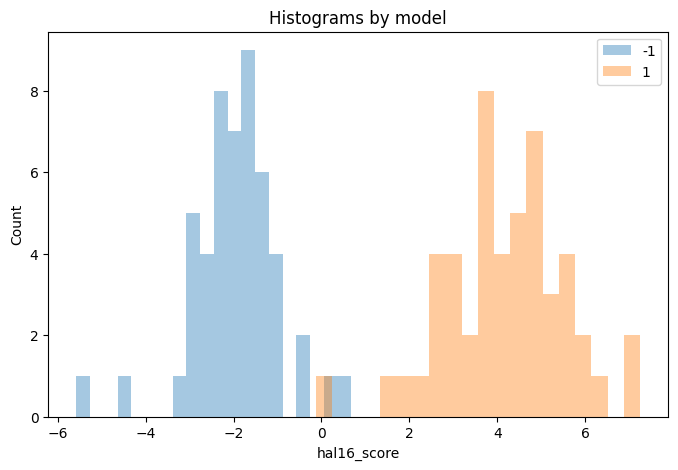

In [153]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for label in [-1,1]:
    subset = output[output["label"] == label]["hal16_score"]
    plt.hist(subset, bins=20, alpha=0.4, label=label)

plt.xlabel("hal16_score")
plt.ylabel("Count")
plt.title("Histograms by model")
plt.legend()
plt.show()


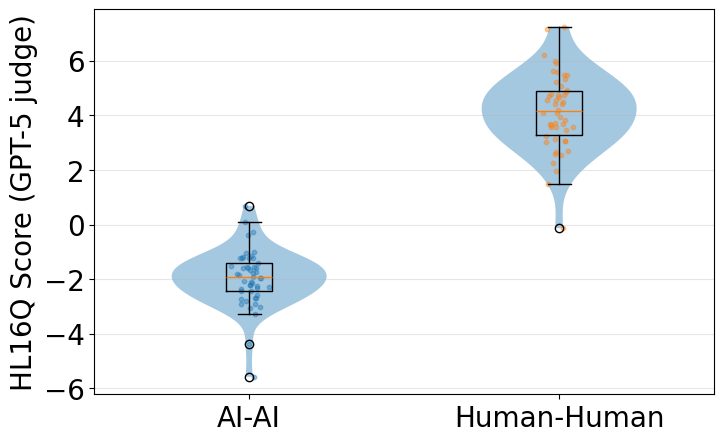

In [154]:
import numpy as np
import matplotlib.pyplot as plt

data_neg1 = output[output["label"] == -1]["hal16_score"].dropna().values
data1 = output[output["label"] == 1]["hal16_score"].dropna().values

data = [data_neg1, data1]
positions = [0, 1]

plt.figure(figsize=(8, 5))

# Violin plots
parts = plt.violinplot(
    data,
    positions=positions,
    showextrema=False
)

for pc in parts["bodies"]:
    pc.set_alpha(0.4)

# Box plots
plt.boxplot(
    data,
    positions=positions,
    widths=0.15
)

# Jittered points
rng = np.random.default_rng(42)

for position, values in zip(positions, data):
    plt.scatter(
        rng.normal(position, 0.03, size=len(values)),
        values,
        s=10,
        alpha=0.4
    )

plt.xticks(
    positions,
    ["AI-AI", "Human-Human"],
    fontsize=20
)

plt.ylabel("HL16Q Score (GPT-5 judge)", fontsize=20)
plt.yticks(fontsize=20)

plt.grid(True, axis="y", alpha=0.3)

plt.savefig(
    "Plots/ood.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [155]:
import numpy as np
from scipy.stats import mannwhitneyu, ttest_ind
from sklearn.utils import resample

ha = output[output["label"] == -1]["hal16_score"].dropna().values
hh = output[output["label"] == 1]["hal16_score"].dropna().values

# 1) Mann–Whitney (one-sided)
u, p_mwu = mannwhitneyu(hh, ha, alternative="greater")

# 2) Welch t-test (one-sided)
t, p_t = ttest_ind(hh, ha, equal_var=False, alternative="greater")

# 3) Mean difference + bootstrap CI
delta = hh.mean() - ha.mean()

boot = []
for _ in range(10000):
    boot.append(resample(hh).mean() - resample(ha).mean())
ci = np.percentile(boot, [2.5, 97.5])

# 4) Cliff’s delta
def cliffs_delta(x, y):
    return (np.sum(x[:,None] > y) - np.sum(x[:,None] < y)) / (len(x)*len(y))

delta_cliff = cliffs_delta(hh, ha)

print({
    "MWU_p": p_mwu,
    "Welch_p": p_t,
    "mean_diff": delta,
    "CI_95": ci,
    "cliffs_delta": delta_cliff
})


{'MWU_p': np.float64(3.982614553664213e-18), 'Welch_p': np.float64(1.7003640834270388e-42), 'mean_diff': np.float64(6.100312619182359), 'CI_95': array([5.61634936, 6.57215732]), 'cliffs_delta': np.float64(0.9984)}


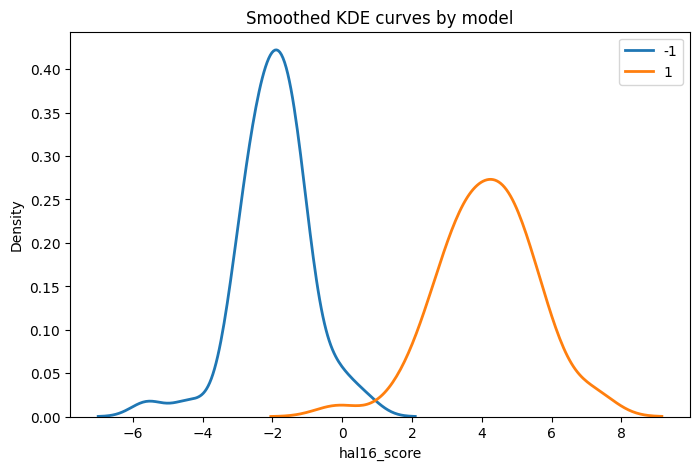

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

for label in [-1,1]:
    subset = output[output["label"] == label]["hal16_score"]
    sns.kdeplot(subset, fill=False, linewidth=2, label=label)

plt.xlabel("hal16_score")
plt.ylabel("Density")
plt.title("Smoothed KDE curves by model")
plt.legend()
plt.show()


In [157]:
std_val = output["hal16_score"].std()
mean = output["hal16_score"].mean()
print(mean, std_val)

1.0885540804888199 3.2990677315593286


In [158]:
means = output.groupby("label")["hal16_score"].mean().sort_values(ascending=False)
print(means)

label
 1    4.138710
-1   -1.961602
Name: hal16_score, dtype: float64


<Figure size 800x500 with 0 Axes>

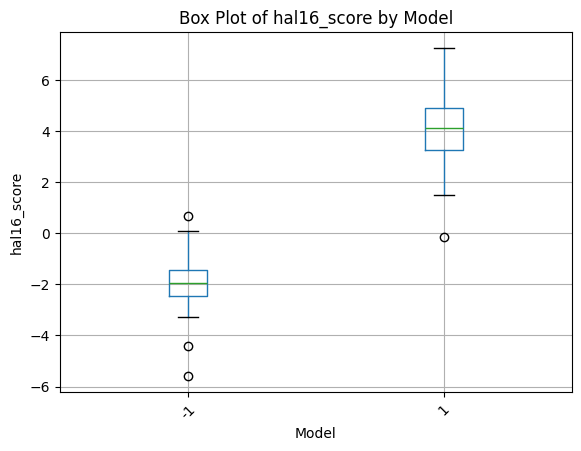

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
output.boxplot(column="hal16_score", by="label")
plt.title("Box Plot of hal16_score by Model")
plt.suptitle("")
plt.xlabel("Model")
plt.ylabel("hal16_score")
plt.xticks(rotation=45)
plt.show()


In [160]:
from scipy.stats import ttest_ind
import numpy as np

a = output.loc[output.label == 1, "hal16_score"].dropna().values
b = output.loc[output.label == -1, "hal16_score"].dropna().values

t_stat, p_two = ttest_ind(a, b, equal_var=False)

# convert two-sided p to one-sided
p_one = p_two / 2 if np.mean(a) > np.mean(b) else 1.0

print({
    "mean_A": np.mean(a),
    "mean_B": np.mean(b),
    "p_one_sided": p_one
})

{'mean_A': np.float64(4.138710390079999), 'mean_B': np.float64(-1.96160222910236), 'p_one_sided': np.float64(1.7003640834270388e-42)}


In [161]:
from scipy.stats import mannwhitneyu
import numpy as np

u, p = mannwhitneyu(a, b, alternative="greater")

print({
    "mean_1": np.mean(a),
    "mean_0": np.mean(b),
    "p_one_sided": p
})


{'mean_1': np.float64(4.138710390079999), 'mean_0': np.float64(-1.96160222910236), 'p_one_sided': np.float64(3.982614553664213e-18)}


In [162]:
def cliffs_delta(a, b):
    return (np.sum(a[:, None] > b) - np.sum(a[:, None] < b)) / (len(a) * len(b))

print({"cliffs_delta": cliffs_delta(a, b)})

{'cliffs_delta': np.float64(0.9984)}


In [163]:
import numpy as np
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

# data_neg1 = AI-AI
# data1 = Human-Human

# Mann-Whitney U test: one-sided, testing Human-Human > Human-AI
u_stat, p_value = mannwhitneyu(data1, data_neg1, alternative="greater")

# AUC: probability that a random Human-Human dialogue scores higher than a random Human-AI dialogue
y_true = np.array([0] * len(data_neg1) + [1] * len(data1))
scores = np.concatenate([data_neg1, data1])
auc = roc_auc_score(y_true, scores)

# Rank-biserial correlation
# For Mann-Whitney U, rank-biserial = 2*AUC - 1
rank_biserial = 2 * auc - 1

# Mean difference
mean_diff = np.mean(data1) - np.mean(data_neg1)

# Bootstrap 95% CI for mean difference
rng = np.random.default_rng(42)
boot_diffs = []

for _ in range(10000):
    sample0 = rng.choice(data_neg1, size=len(data_neg1), replace=True)
    sample1 = rng.choice(data1, size=len(data1), replace=True)
    boot_diffs.append(np.mean(sample1) - np.mean(sample0))

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

print(f"AI-AI mean: {np.mean(data_neg1):.2f}")
print(f"Human-Human mean: {np.mean(data1):.2f}")
print(f"Mean difference: {mean_diff:.2f}")
print(f"95% bootstrap CI: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Mann-Whitney U: {u_stat:.2f}")
print(f"p-value: {p_value:.6g}")
print(f"AUC: {auc:.3f}")
print(f"Rank-biserial correlation: {rank_biserial:.3f}")

AI-AI mean: -1.96
Human-Human mean: 4.14
Mean difference: 6.10
95% bootstrap CI: [5.63, 6.58]
Mann-Whitney U: 2498.00
p-value: 3.98261e-18
AUC: 0.999
Rank-biserial correlation: 0.998
